# Exploration de données

Ce notebook a pour objectif d'explorer le dataset M5 afin de comprendre la structure des données, identifier des patterns, détecter d'éventuelles anomalies et préparer les futures étapes de modélisation.

## Première lecture du fichier

In [1]:
import pandas as pd

df = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")
df.head() # affichage des 5 premières lignes

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


## Informations globales

### Dimension

In [12]:
df.shape

(30490, 1947)

On a donc 30490 produits et 1941 jours (environ 5 ans). Le dataset est très riche et complexe.
    On a beaucoup de produits mais aussi beaucoup de jours. Il sera peut être possible d'analyser des tendances ou une saisonnalité.

### Informations sur le dataset

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


Il y a 1941 colonnes en int (correspondant à des ventes) et 6 colonnes en object (correspondant à des catégories). Le dataset est assez lourd (mémoire : 453 MB environ).
Le dataset semble bien structuré : il n'y a pas de mélange de types et la structure est claire. Il n'y aura pas besoin de faire de gros nettoyage technique : les données sont exploitables directement.

### Valeurs manquantes

In [14]:
df.isnull().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1937      0
d_1938      0
d_1939      0
d_1940      0
d_1941      0
Length: 1947, dtype: int64

Notre dataset est propre mais on observe beaucoup de 0 (jour sans vente). 

### Statistiques de bases 

In [16]:
df.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,1.445490,1.781174,1.965267,1.389374,1.271794,1.216661,1.212299,1.395605,1.689669,1.782158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,3.656824,4.426550,4.706284,3.313292,3.126178,3.000348,2.955910,3.514318,4.089208,4.284356
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,143.000000,156.000000,187.000000,98.000000,90.000000,77.000000,84.000000,110.000000,156.000000,117.000000


On observe en moyenne une vente par jour mais la médiane est à 0. Cela signifie qu'il n'y a aucune vente la majorité du temps, et des gros pics de demandes (jusqu'à 400). L'écart type est élevé indiquant une forte variabilité.

### Structure du dataset

On peut voir 3 niveaux : 
    
    1. Produit (item_id)
    
    2. Catégorie (dept_id, cat_id)
    
    3. Localisation (store_id, state_id)
    
    4. Temps (d_1 -> d_1941)
    
C'est donc un dataset hiérarchique.

### Visualisation d'une série

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


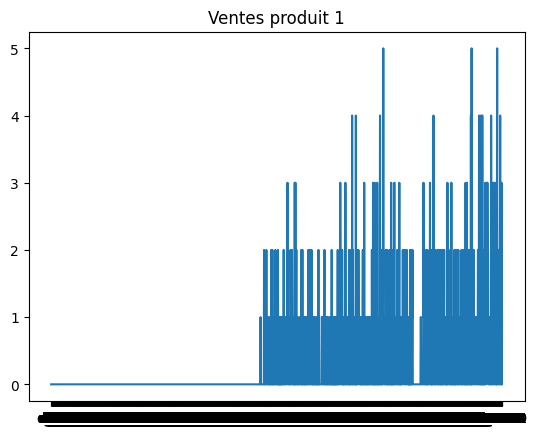

In [18]:
import matplotlib.pyplot as plt

sample = df.iloc[0,6:]

plt.plot(sample)
plt.title("Ventes produit 1")
plt.show()

On observe une longue période à 0 puis l'apparition des ventes. Les pics sont irréguliers.

### Histogramme global

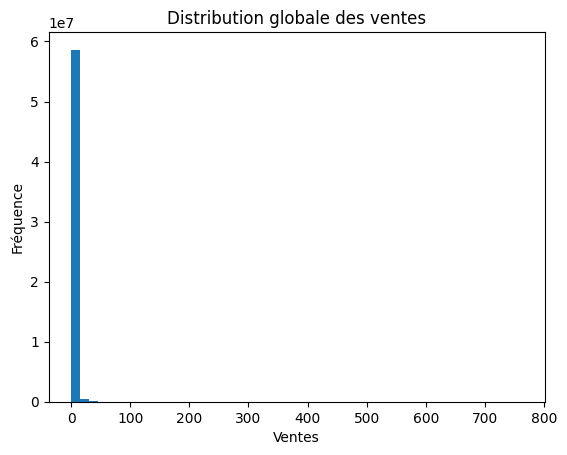

In [5]:
import matplotlib.pyplot as plt
colonnes_ventes = [c for c in df.columns if c.startswith("d_")]
plt.hist(df[colonnes_ventes].values.flatten(), bins=50)
plt.title("Distribution globale des ventes")
plt.xlabel("Ventes")
plt.ylabel("Fréquence")
plt.show()

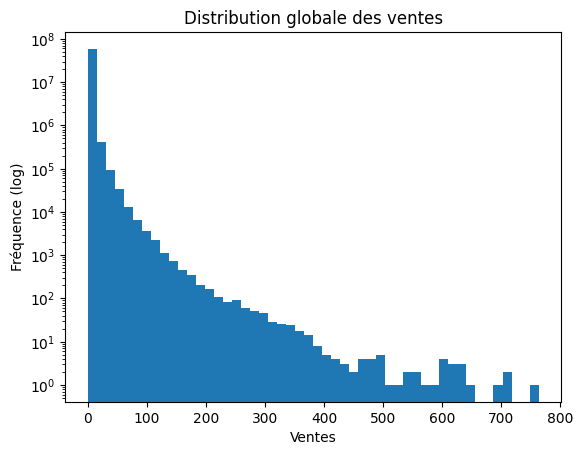

In [2]:
import matplotlib.pyplot as plt
colonnes_ventes = [c for c in df.columns if c.startswith("d_")]
plt.hist(df[colonnes_ventes].values.flatten(), bins=50)
plt.yscale("log")
plt.title("Distribution globale des ventes")
plt.xlabel("Ventes")
plt.ylabel("Fréquence (log)")
plt.show()

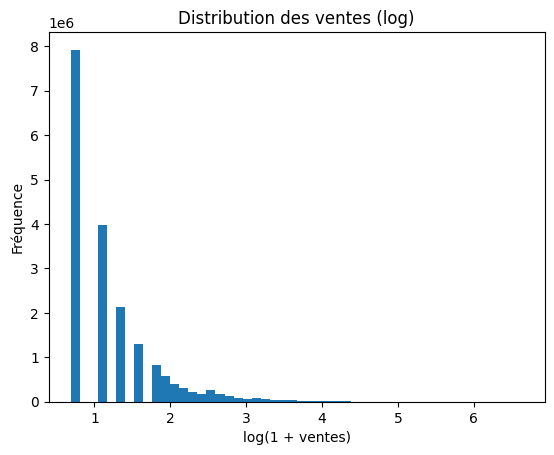

In [4]:
import numpy as np

data = df[colonnes_ventes].values.flatten()
data = data[data > 0]  # éviter log(0)

plt.hist(np.log1p(data), bins=50)
plt.title("Distribution des ventes (log)")
plt.xlabel("log(1 + ventes)")
plt.ylabel("Fréquence")
plt.show()

### Conclusion

La demande est non continue, irrégulière et sera probablement difficile à prédire. Un modèle linéaire simple ne conviendra donc probablement pas.